# Human Activity Recognition with Wifi

In [66]:
import numpy as np
import numpy.random as rnd
import torch
import matplotlib.pyplot as plt

from models.DopplerDataset import * 
from models.SHARP import *
from utilities.training import *
from utilities.plotting import *
from utilities.dataset_separation import *

from time import time 
from torchvision.transforms import Compose, ToTensor, RandomHorizontalFlip, RandomVerticalFlip
from torch.utils.data import DataLoader
from os import listdir, makedirs, path
from glob import glob
from tqdm import tqdm

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Separating training dataset and test dataset

In [67]:
DEBUG_MODE                 = True

TRAIN_DATASET_PATH  = "doppler_traces/S1*"
TEST_DATASET_PATH   = "doppler_traces/S2*"
DOPPLER_TRACE_SIZE  = 340

LABELS     = ['W', 'E', 'R', 'J', 'L']
ACTIVITIES = ['Walking', 'Empty', 'Running', 'Jumping', 'Sitting']

create_train_dataset(TRAIN_DATASET_PATH, DOPPLER_TRACE_SIZE, LABELS)
create_test_dataset(TEST_DATASET_PATH, DOPPLER_TRACE_SIZE, LABELS)

Datasets are already splitted!

Dataset is already splitted!



## Loading Dataset

Loading dataset doppler_traces_train in memory...


3256it [00:01, 1811.38it/s]


Dataset is loaded!

---------- DATASET INFO ----------
Dataset directory:
doppler_traces_train
Labels dictionary:
{'W': 0, 'E': 1, 'R': 2, 'J': 3, 'L': 4}
----------------------------------

Loading dataset doppler_traces_test in memory...


2816it [00:01, 1876.76it/s]


Dataset is loaded!

---------- DATASET INFO ----------
Dataset directory:
doppler_traces_test
Labels dictionary:
{'W': 0, 'E': 1, 'R': 2, 'J': 3, 'L': 4}
----------------------------------



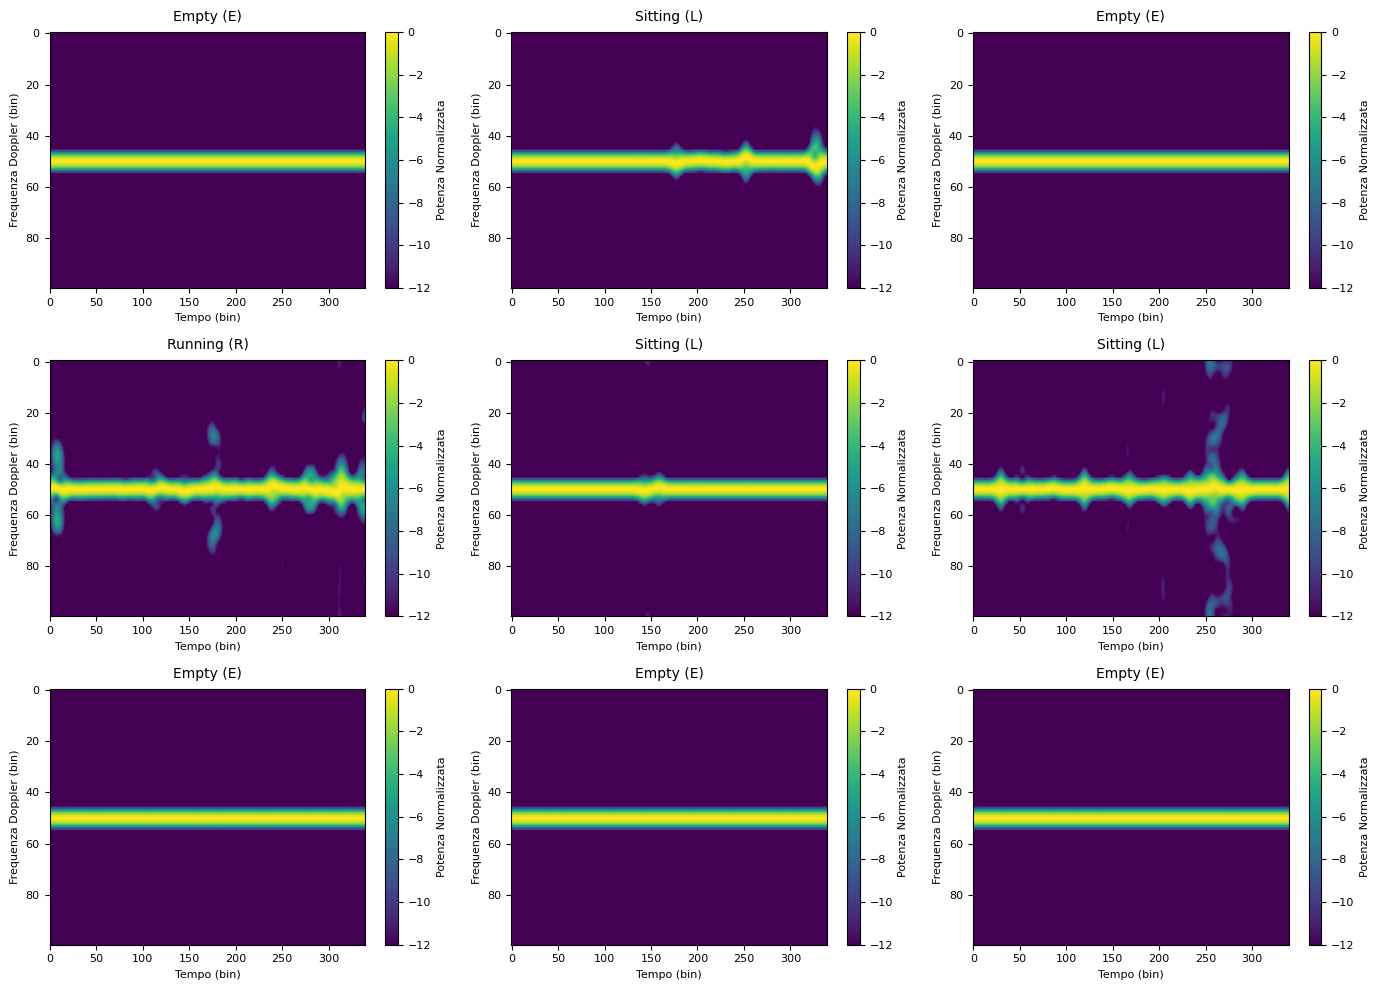

In [68]:
labels_map = {label:idx for idx, label in enumerate(LABELS)}

batch_size = 128
train_dataset  = DopplerDataset("doppler_traces_train", labels_map)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
train_dataset.getInfo()

test_dataset  = DopplerDataset("doppler_traces_test", labels_map)
test_dataloader = DataLoader(test_dataset, batch_size=4, shuffle=False)
test_dataset.getInfo()

cols, rows = 3, 3
fig, axes = plt.subplots(rows, cols, figsize=(14, 10))
axes = axes.flatten()  

for i in range(cols * rows):
    sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
    img, label_idx = train_dataset[sample_idx]
    
    ax = axes[i]
    im = ax.imshow(img[0, :, :], aspect='auto', cmap='viridis')
    
    ax.set_title(f"{ACTIVITIES[label_idx]} ({LABELS[label_idx]})", fontsize=10, pad=8)
    
    ax.set_xlabel("Tempo (bin)", fontsize=8)
    ax.set_ylabel("Frequenza Doppler (bin)", fontsize=8)
    ax.tick_params(axis='both', which='major', labelsize=8)
    
    cbar = fig.colorbar(im, ax=ax)
    cbar.ax.tick_params(labelsize=8)
    cbar.set_label('Potenza Normalizzata', fontsize=8)

plt.tight_layout()
plt.show()

## Training of SHARP architecure

In [69]:
sharp_model = SHARP(n_features=len(ACTIVITIES))

learning_rate = 1e-4
device    = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=sharp_model.parameters(), lr=learning_rate)

if DEBUG_MODE:
    #### CHECKING DATA TYPES 
    x, y = next(iter(train_dataloader))
    print(x.dtype)
    print(next(sharp_model.parameters()).dtype)
    ### DEVICE
    print(f"Device: {device}")

torch.float32
torch.float32
Device: mps


In [70]:
epochs = 25
train_loss, test_loss, train_acc, test_acc, _ = train_model(sharp_model, train_dataloader, test_dataloader, epochs, loss_fn, optimizer, device, verbosity=True)

Starting model training...
Completed epochs: 0/25 ------ Time (total): 0.00 ------ Time (relative): 0.00

Loss: 1.61288e+00 --- Accuracy: 21.094% ---Samples:   128/ 3256
Loss: 1.53497e+00 --- Accuracy: 29.759% ---Samples:  1408/ 3256
Loss: 1.44367e+00 --- Accuracy: 33.371% ---Samples:  2688/ 3256
Loss: 1.41418e+00 --- Accuracy: 33.263% ---Samples:  3328/ 3256
Test Error: 
 Accuracy: 45.7%, Avg loss: 1.391468 

Completed epochs: 1/25 ------ Time (total): 3.43 ------ Time (relative): 3.43

Loss: 1.43862e+00 --- Accuracy: 37.500% ---Samples:   128/ 3256
Loss: 1.36211e+00 --- Accuracy: 39.560% ---Samples:  1408/ 3256
Loss: 1.31196e+00 --- Accuracy: 40.513% ---Samples:  2688/ 3256
Loss: 1.24932e+00 --- Accuracy: 39.423% ---Samples:  3328/ 3256
Test Error: 
 Accuracy: 46.0%, Avg loss: 1.274232 

Completed epochs: 2/25 ------ Time (total): 6.40 ------ Time (relative): 2.97

Loss: 1.29208e+00 --- Accuracy: 38.281% ---Samples:   128/ 3256
Loss: 1.21879e+00 --- Accuracy: 44.105% ---Samples:  140

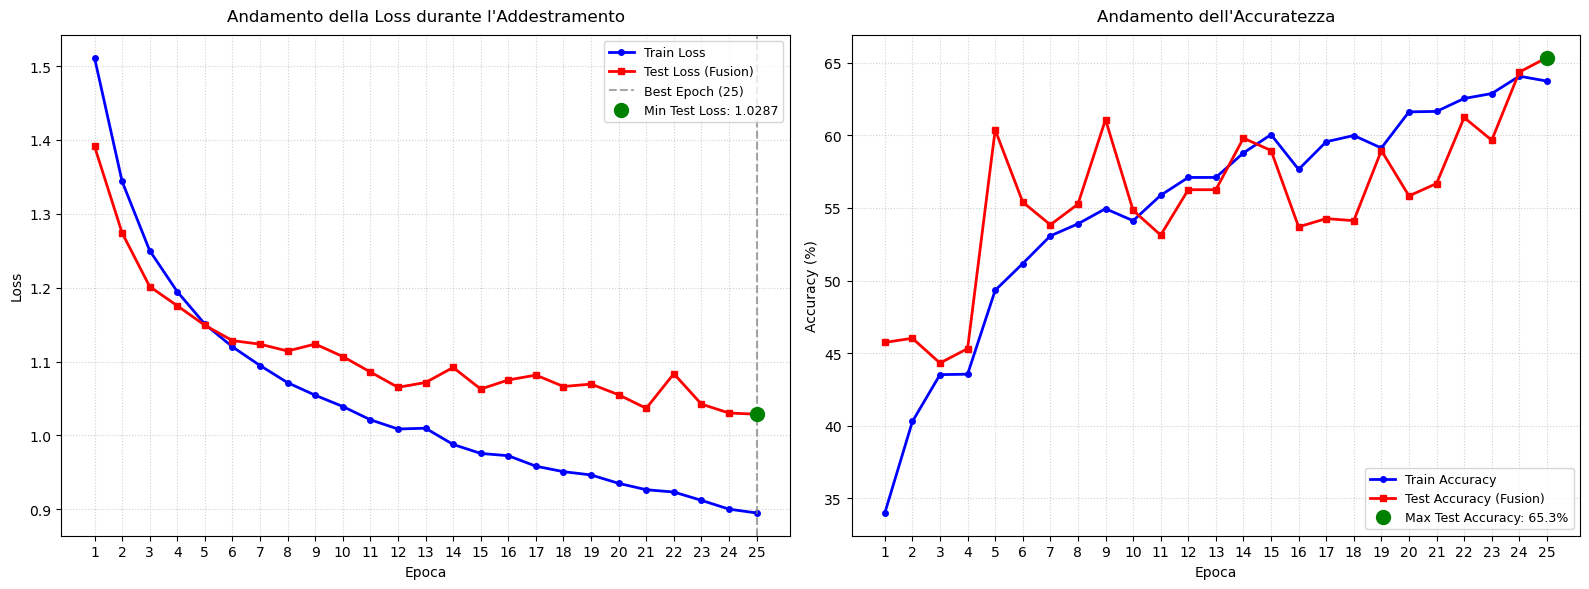

In [71]:
plot_loss(train_loss, test_loss, train_acc*100, test_acc)